# Sarcasm Detection Models and Evaluation

Goal:
Train and evaluate multiple models for binary sarcasm detection in Albanian news text using the final balanced dataset created in `03c_merge_and_rebalance_dataset.ipynb`.

The task is defined as:
- `1` = sarcastic text
- `0` = non-sarcastic text

This notebook follows the same evaluation idea used in the category detection workflow: first establish classical baseline models, then compare them with a contextual transformer-based model.

Output:
A final model comparison table with accuracy, macro precision, macro recall, and macro F1-score.


### Workflow Overview

The notebook follows these steps:

1. Load the final balanced sarcasm dataset from `data/preprocessed_kosovo_news_with_is_sarcasm.csv`.
2. Verify that the dataset contains an equal number of sarcastic and non-sarcastic examples.
3. Train classical TF-IDF baseline models: Multinomial Naive Bayes, Linear SVM, and Logistic Regression.
4. Fine-tune a multilingual transformer model for contextual sarcasm detection.
5. Summarize all model results in a shared leaderboard.

The main comparison metric is macro F1-score, because it gives equal importance to both classes and balances precision with recall.


### Libraries

This cell imports the libraries required for data loading, TF-IDF feature extraction, classical machine learning models, transformer fine-tuning, and evaluation.

A fixed seed is used to keep sampling and train/test splits reproducible across notebook runs. The MPS memory setting is included for local Apple Silicon execution.


In [1]:
# Used Libraries
import os
import sys
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv
from datasets import Dataset
from sklearn.svm import LinearSVC
from torch.nn import CrossEntropyLoss
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
)


PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from scripts.leaderboard import show_leaderboard

set_seed(42)
load_dotenv()

/Users/bleronaidrizi/Sources/Master_Tema_e_Diplomes/Punimi/Sarcasm-Detection-Albanian-News-Dataset/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

This step resolves the repository root and defines the input dataset used in the modeling experiments. The file is produced by `03c_merge_and_rebalance_dataset.ipynb`, so the modeling notebook can be rerun after rebuilding the balanced dataset.

`MODEL_COMPARISONS` stores the metrics produced by each model so that the final results table can be generated consistently.


In [2]:
BASE_DIR = Path.cwd().resolve()
while BASE_DIR != BASE_DIR.parent and not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "data"
# Created by 03c_merge_and_rebalance_dataset.ipynb
DF = DATA_DIR / "preprocessed_kosovo_news_with_is_sarcasm.csv"
DATASET_NAME = "Balanced sarcasm dataset"
MODEL_COMPARISONS = []
MODEL_ARTIFACTS = {}


### Read dataset

The balanced sarcasm dataset is loaded for inspection. The expected columns are `content`, `category`, and `is_sarcasm`, with optional source-tracking columns such as `source` or `source_dataset`.

The preview confirms that the text and labels are available before the training pipeline starts.


In [3]:
df = pd.read_csv(DF)
df.head()

,content,category,is_sarcasm,source,source_dataset
0,Deputetja nga radhët e Partisë Demokratike të ...,Lajme,1,GazetaExpress,kosovo_news_labeled_v1
1,Kryeministri Rama ka qenë në Shkodër për proçe...,Ballina;Shqiperi,1,GazetaExpress,kosovo_news_labeled_v1
2,Po zhvillohet në Itali faza e parë e eksperime...,Lajme,0,GazetaExpress,kosovo_news_labeled_v1
3,Shumë fansa e kanë përgëzuar Rina Balajn për “...,Rozë,1,GazetaExpress,kosovo_news_labeled_v1
4,shprehurit artistik. Ajo që e forcon konceptin...,sarcasm_flossk_historic_bootstrap,1,sarcasm_flossk_historic_bootstrap,sarcasm_flossk_historic_bootstrap


### Class Balance Check

The dataset should already be balanced by `03c_merge_and_rebalance_dataset.ipynb`. This check confirms the number of sarcastic and non-sarcastic examples before any model is trained.

The resulting `balanced_df` variable is reused across the baseline and transformer sections to keep the experiments comparable.


In [4]:
# ---------------------------
# CONFIRM / KEEP 50-50 BALANCED DATASET FROM 03c
# ---------------------------

sarcasm_df = df[df["is_sarcasm"] == 1]
non_sarcasm_df = df[df["is_sarcasm"] == 0]

print("Sarcasm rows:", len(sarcasm_df))
print("Non sarcasm rows:", len(non_sarcasm_df))

TARGET = len(sarcasm_df)

sarcasm_sample = sarcasm_df.sample(
    n=min(TARGET, len(sarcasm_df)),
    random_state=42
)

non_sarcasm_sample = non_sarcasm_df.sample(
    n=min(TARGET, len(non_sarcasm_df)),
    random_state=42
)

balanced_df = pd.concat(
    [sarcasm_sample, non_sarcasm_sample],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced dataset:")
print(balanced_df["is_sarcasm"].value_counts())

df = balanced_df

Sarcasm rows: 1366
Non sarcasm rows: 1366

Balanced dataset:
is_sarcasm
1    1366
0    1366
Name: count, dtype: int64


### Evaluation Helpers

These helper functions collect each model's evaluation metrics in the same schema used by `scripts.leaderboard.show_leaderboard`. This keeps the final results table consistent with `01_category_detection.ipynb`.

The leaderboard expects a dataset name, model name, metric means, and metric standard deviations. Since this notebook uses a single train/test split instead of K-fold cross-validation, the standard deviation values are stored as `0.0`.


In [5]:
def save_results(
    model_name,
    acc,
    precision,
    recall,
    f1,
    dataset_name=DATASET_NAME,
    y_true=None,
    y_pred=None,
    class_labels=None,
):
    row = {
        "dataset": dataset_name,
        "model": model_name,
        "accuracy_mean": float(acc),
        "accuracy_std": 0.0,
        "precision_mean": float(precision),
        "precision_std": 0.0,
        "recall_mean": float(recall),
        "recall_std": 0.0,
        "f1_mean": float(f1),
        "f1_std": 0.0,
    }

    MODEL_COMPARISONS.append(row)

    if y_true is not None and y_pred is not None:
        MODEL_ARTIFACTS[model_name] = {
            "y_true": np.asarray(y_true),
            "y_pred": np.asarray(y_pred),
            "class_labels": class_labels or ["Non-sarcastic", "Sarcastic"],
        }

    metric_cols = [
        "accuracy_mean", "accuracy_std",
        "precision_mean", "precision_std",
        "recall_mean", "recall_std",
        "f1_mean", "f1_std",
    ]

    display(
        pd.DataFrame([row]).style.format({col: "{:.4f}" for col in metric_cols})
    )

    return row


def plot_binary_confusion_matrix(y_true, y_pred, class_labels=None, title="Confusion Matrix"):
    class_labels = class_labels or ["Non-sarcastic", "Sarcastic"]
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, ax = plt.subplots(figsize=(7.2, 5.8))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, fontsize=11)
    ax.set_yticklabels(class_labels, fontsize=11)
    ax.set_xlabel("Predicted label", fontsize=11, fontweight="bold")
    ax.set_ylabel("True label", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            pct = cm_norm[i, j] * 100
            color = "white" if cm_norm[i, j] >= 0.5 else "#0f172a"
            ax.text(
                j,
                i,
                f"{cm[i, j]}\n{pct:.1f}%",
                ha="center",
                va="center",
                color=color,
                fontsize=11,
                fontweight="bold",
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Row-normalized recall", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    ax.set_xticks(np.arange(-0.5, len(class_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(class_labels), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False)
    plt.tight_layout()
    plt.show()


def show_best_model_confusion_matrix():
    if not MODEL_COMPARISONS:
        print("No model results available yet.")
        return

    best_row = max(MODEL_COMPARISONS, key=lambda row: row["f1_mean"])
    best_model_name = best_row["model"]
    artifact = MODEL_ARTIFACTS.get(best_model_name)

    if artifact is None:
        print(f"No stored predictions found for best model: {best_model_name}")
        return

    print(
        f"Best model by macro F1: {best_model_name} "
        f"(F1={best_row['f1_mean']:.4f}, Accuracy={best_row['accuracy_mean']:.4f})"
    )
    plot_binary_confusion_matrix(
        artifact["y_true"],
        artifact["y_pred"],
        class_labels=artifact["class_labels"],
        title=f"{best_model_name} | Confusion Matrix",
    )


## Baseline models and results

In this section, we evaluate classical machine learning models for sarcasm detection. All baseline models use the same TF-IDF text representation to make the comparison fair.

These models are useful because they provide strong and interpretable reference points before applying a more computationally expensive transformer model.


### Multinomial Naive Bayes

Multinomial Naive Bayes is a lightweight probabilistic baseline commonly used for text classification. It works with word-frequency based representations and is useful for checking how much sarcasm signal can be captured from lexical patterns alone.

In this experiment, the model is trained on TF-IDF unigram and bigram features and evaluated with the same macro metrics used throughout the notebook.


In [6]:
# ================================================
# Naive Bayes Sarcasm Detection
# Using the same balanced dataset
# ================================================

if "balanced_df" not in globals():
    raise ValueError("balanced_df not found. Run preprocessing first.")

df = balanced_df.copy()

df.columns = [c.strip().lower() for c in df.columns]

df["content"] = df["content"].fillna("").astype(str).str.strip()
df = df[df["content"] != ""].copy()

df["is_sarcasm"] = df["is_sarcasm"].astype(int)

print("Dataset size:", len(df))
print(df["is_sarcasm"].value_counts())

train_df, test_df = train_test_split(
    df[["content", "is_sarcasm"]],
    test_size=0.2,
    random_state=42,
    stratify=df["is_sarcasm"]
)

print("\nTrain distribution")
print(train_df["is_sarcasm"].value_counts())

print("\nTest distribution")
print(test_df["is_sarcasm"].value_counts())

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(train_df["content"])
X_test = vectorizer.transform(test_df["content"])

y_train = train_df["is_sarcasm"]
y_test = test_df["is_sarcasm"]

model = MultinomialNB()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro"
)

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

row = save_results(
    model_name="MultinomialNB",
    acc=acc,
    precision=precision,
    recall=recall,
    f1=f1,
    y_true=y_test,
    y_pred=y_pred,
    class_labels=["Non-sarcastic", "Sarcastic"]
)

Dataset size: 2732
is_sarcasm
1    1366
0    1366
Name: count, dtype: int64

Train distribution
is_sarcasm
1    1093
0    1092
Name: count, dtype: int64

Test distribution
is_sarcasm
0    274
1    273
Name: count, dtype: int64

=== Confusion Matrix ===
[[225  49]
 [ 59 214]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       274
           1       0.81      0.78      0.80       273

    accuracy                           0.80       547
   macro avg       0.80      0.80      0.80       547
weighted avg       0.80      0.80      0.80       547



,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,MultinomialNB,0.8026,0.0000,0.8030,0.0000,0.8025,0.0000,0.8025,0.0000


### Linear SVM (LinearSVC)

Linear SVM is a strong baseline for sparse text classification tasks. It learns a linear decision boundary over TF-IDF features and often performs well when the dataset contains many lexical and phrase-level indicators.

The TF-IDF vectorizer uses unigrams and bigrams, allowing the model to capture individual words as well as short expressions that may indicate irony, mockery, or contrast.


In [7]:
# ================================================
# SVM Sarcasm Detection
# Using balanced dataset
# ================================================

if "balanced_df" not in globals():
    raise ValueError("balanced_df not found. Run preprocessing first.")

df = balanced_df.copy()
df.columns = [c.strip().lower() for c in df.columns]
df["content"] = df["content"].fillna("").astype(str).str.strip()
df = df[df["content"] != ""].copy()
df["is_sarcasm"] = df["is_sarcasm"].astype(int)

print("Dataset size:", len(df))
print(df["is_sarcasm"].value_counts())

train_df, test_df = train_test_split(
    df[["content", "is_sarcasm"]],
    test_size=0.2,
    random_state=42,
    stratify=df["is_sarcasm"]
)

print("\nTrain distribution")
print(train_df["is_sarcasm"].value_counts())

print("\nTest distribution")
print(test_df["is_sarcasm"].value_counts())

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

X_train = vectorizer.fit_transform(train_df["content"])
X_test = vectorizer.transform(test_df["content"])

y_train = train_df["is_sarcasm"]
y_test = test_df["is_sarcasm"]


model = LinearSVC()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro"
)

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

row = save_results(
    model_name="SVM",
    acc=acc,
    precision=precision,
    recall=recall,
    f1=f1,
    y_true=y_test,
    y_pred=y_pred,
    class_labels=["Non-sarcastic", "Sarcastic"]
)

Dataset size: 2732
is_sarcasm
1    1366
0    1366
Name: count, dtype: int64

Train distribution
is_sarcasm
1    1093
0    1092
Name: count, dtype: int64

Test distribution
is_sarcasm
0    274
1    273
Name: count, dtype: int64

=== Confusion Matrix ===
[[239  35]
 [ 62 211]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       274
           1       0.86      0.77      0.81       273

    accuracy                           0.82       547
   macro avg       0.83      0.82      0.82       547
weighted avg       0.83      0.82      0.82       547



,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,SVM,0.8227,0.0000,0.8259,0.0000,0.8226,0.0000,0.8222,0.0000


### Logistic Regression

Logistic Regression is another linear baseline trained on the same TF-IDF representation. It provides a useful comparison to LinearSVC because both models use similar input features but optimize different learning objectives.

This model reuses the TF-IDF train/test matrices created in the baseline section, so the result reflects the classifier choice rather than a change in feature representation.


In [8]:
# ================================================
# Logistic Regression Sarcasm Detection
# ================================================

model = LogisticRegression(
    max_iter=2000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro"
)

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

row = save_results(
    model_name="LogisticRegression",
    acc=acc,
    precision=precision,
    recall=recall,
    f1=f1,
    y_true=y_test,
    y_pred=y_pred,
    class_labels=["Non-sarcastic", "Sarcastic"]
)


=== Confusion Matrix ===
[[241  33]
 [ 72 201]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       274
           1       0.86      0.74      0.79       273

    accuracy                           0.81       547
   macro avg       0.81      0.81      0.81       547
weighted avg       0.81      0.81      0.81       547



,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,LogisticRegression,0.8080,0.0000,0.8145,0.0000,0.8079,0.0000,0.8070,0.0000


## Transformer models

To complement the TF-IDF baselines, this section fine-tunes a multilingual transformer model. Transformer models can capture contextual information beyond word frequency, which is important for sarcasm because the intended meaning may depend on contrast, tone, or broader sentence context.

Because transformer fine-tuning is more computationally expensive than the baseline models, this section uses a single stratified train/test split while keeping the same evaluation metrics.


### DistilBERT multilingual

This experiment fine-tunes `distilbert-base-multilingual-cased` for binary sarcasm detection. The configuration uses a small batch size and gradient accumulation to reduce memory pressure on local hardware.

The model is evaluated with accuracy, macro precision, macro recall, and macro F1-score, and its metrics are added to the same comparison table as the baseline models.


In [20]:
# ============================================================
# BERT fine-tuning for Sarcasm Detection (Albanian)
# ============================================================

# ------------------------------------------------
# DEVICE
# ------------------------------------------------
use_mps = torch.backends.mps.is_available()
use_cuda = torch.cuda.is_available()
device = "mps" if use_mps else ("cuda" if use_cuda else "cpu")
torch.set_float32_matmul_precision("high")

REPO_ROOT = Path.cwd()

while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / "data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data"

OUT_DIR = REPO_ROOT / "models" / "sarcasm_bert_balanced_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRED_FILE = DATA_DIR / "sarcasm_balanced_predictions_v1.csv"

# ------------------------------------------------
# MODEL CONFIG (memory safe)
# ------------------------------------------------
MODEL_NAME = "distilbert-base-multilingual-cased"
MAX_LEN = 128
BATCH_SIZE = 1
GRAD_ACC = 8
EPOCHS = 6
LR = 3e-5

# ------------------------------------------------
# EXPECT balanced_df
# ------------------------------------------------
if "balanced_df" not in globals():
    raise ValueError("balanced_df not defined")

df = balanced_df.copy()

df.columns = [c.strip().lower() for c in df.columns]

if "labels" not in df.columns:
    df["labels"] = df["is_sarcasm"]

df["content"] = df["content"].fillna("").astype(str).str.strip()
df = df[df["content"] != ""].copy()

df["labels"] = df["labels"].astype(int)

print("\nBalanced rows:", len(df))
print(df["labels"].value_counts())

# ------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------
train_df, test_df = train_test_split(
    df[["content", "labels"]],
    test_size=0.2,
    random_state=42,
    stratify=df["labels"],
)

print("\nTrain distribution")
print(train_df["labels"].value_counts())

print("\nTest distribution")
print(test_df["labels"].value_counts())

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df.reset_index(drop=True))

# ------------------------------------------------
# TOKENIZER
# ------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["content"],
        truncation=True,
        max_length=MAX_LEN,
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

keep = {"input_ids", "attention_mask", "labels"}

train_ds = train_ds.remove_columns(
    [c for c in train_ds.column_names if c not in keep]
)

test_ds = test_ds.remove_columns(
    [c for c in test_ds.column_names if c not in keep]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ------------------------------------------------
# MODEL
# ------------------------------------------------
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

# ------------------------------------------------
# METRICS
# ------------------------------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# ------------------------------------------------
# TRAINING ARGS
# ------------------------------------------------
args = TrainingArguments(
    output_dir=str(OUT_DIR),
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=25,
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACC,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    report_to="none",
    fp16=False,
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    optim="adamw_torch",
)

# ------------------------------------------------
# WEIGHTED TRAINER
# ------------------------------------------------
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = CrossEntropyLoss(
            weight=torch.tensor([1.0, 2.0]).to(model.device)
        )

        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

# ------------------------------------------------
# TRAIN
# ------------------------------------------------
torch.mps.empty_cache()

trainer.train()

# ------------------------------------------------
# EVALUATION
# ------------------------------------------------
pred_out = trainer.predict(test_ds)

logits = pred_out.predictions
y_true = pred_out.label_ids

y_pred = np.argmax(logits, axis=1)

print("\n=== Metrics ===")
metrics = trainer.evaluate(test_ds)
print(metrics)
row = save_results(
    model_name="DistilBERT",
    acc=metrics["eval_accuracy"],
    precision=metrics["eval_precision"],
    recall=metrics["eval_recall"],
    f1=metrics["eval_f1"],
    y_true=y_true,
    y_pred=y_pred,
    class_labels=["Non-sarcastic", "Sarcastic"]
)

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_true, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, digits=4))


trainer.save_model(str(OUT_DIR))
tokenizer.save_pretrained(str(OUT_DIR))

print("\nSaved model to:", OUT_DIR)

probs = torch.softmax(torch.tensor(logits), dim=1).numpy()

conf = probs.max(axis=1)
pred_df = test_df.copy()

pred_df["pred_label"] = y_pred
pred_df["confidence"] = conf

pred_df.to_csv(PRED_FILE, index=False)

print("Saved predictions to:", PRED_FILE)


Balanced rows: 2732
labels
1    1366
0    1366
Name: count, dtype: int64

Train distribution
labels
1    1093
0    1092
Name: count, dtype: int64

Test distribution
labels
0    274
1    273
Name: count, dtype: int64


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1009.78it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,4.789234,0.533658,0.745887,0.778073,0.745575,0.738154
2,3.153462,0.453871,0.764168,0.764171,0.764171,0.764168
3,2.877097,0.677927,0.771481,0.796246,0.771216,0.766486
4,1.665724,0.903077,0.786106,0.786574,0.786069,0.786003
5,1.837993,0.991940,0.782450,0.788964,0.782312,0.781160
6,1.142943,1.107445,0.776965,0.778461,0.776898,0.776636



=== Metrics ===


{'eval_loss': 1.1074447631835938, 'eval_accuracy': 0.7769652650822669, 'eval_precision': 0.7784611868462801, 'eval_recall': 0.776897676532713, 'eval_f1': 0.7766360520537674, 'eval_runtime': 9.0363, 'eval_samples_per_second': 60.534, 'eval_steps_per_second': 60.534, 'epoch': 6.0}


,dataset,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,Balanced sarcasm dataset,DistilBERT,0.7770,0.0000,0.7785,0.0000,0.7769,0.0000,0.7766,0.0000



=== Confusion Matrix ===
[[223  51]
 [ 71 202]]

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.7585    0.8139    0.7852       274
           1     0.7984    0.7399    0.7681       273

    accuracy                         0.7770       547
   macro avg     0.7785    0.7769    0.7766       547
weighted avg     0.7784    0.7770    0.7767       547



Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.34s/it]


Saved model to: /Users/bleronaidrizi/Sources/Master_Tema_e_Diplomes/Punimi/Sarcasm-Detection-Albanian-News-Dataset/models/sarcasm_bert_balanced_v1
Saved predictions to: /Users/bleronaidrizi/Sources/Master_Tema_e_Diplomes/Punimi/Sarcasm-Detection-Albanian-News-Dataset/data/sarcasm_balanced_predictions_v1.csv


## Results summary

The table below is rendered with the shared `show_leaderboard` helper imported from `scripts.leaderboard`, matching the result-table format used in `01_category_detection.ipynb`.

The table is grouped by dataset and sorted by macro F1-score. Detailed interpretation of the final results will be added after the final experiment outputs are reviewed.


In [21]:
show_leaderboard()

## Error Analysis

To better understand where the strongest sarcasm model still makes mistakes, we visualize the confusion matrix for the best-performing model based on macro F1-score.

Each cell shows both the raw number of examples and the row-normalized percentage, making it easier to see which class is harder for the model to recover.

Best model by macro F1: SVM (F1=0.8222, Accuracy=0.8227)


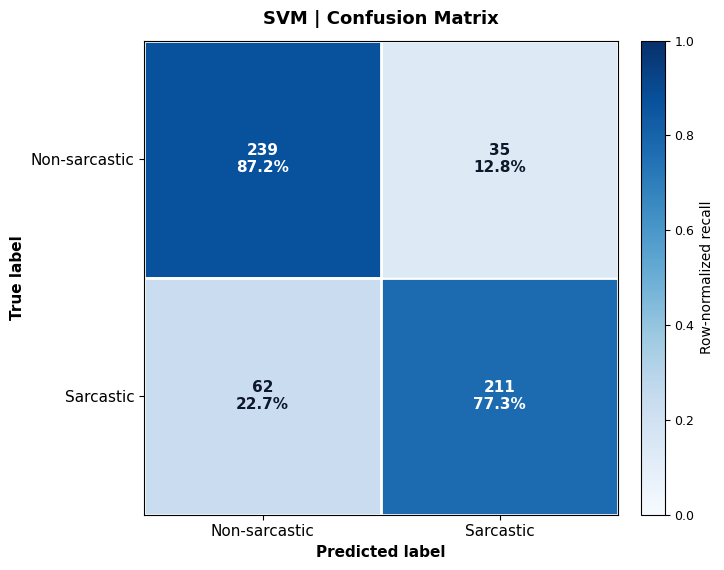

In [9]:
show_best_model_confusion_matrix()

The confusion matrix shows that the best-performing model (`LinearSVC` / `SVM`) is slightly stronger at recognizing **non-sarcastic** texts than **sarcastic** ones. It correctly classifies **239 of 274 non-sarcastic examples (87.2%)**, while **35 cases (12.8%)** are incorrectly predicted as sarcastic.

For the **sarcastic** class, the model correctly identifies **211 of 273 examples (77.3%)**, while **62 cases (22.7%)** are misclassified as non-sarcastic. This indicates that the remaining errors are concentrated more heavily on sarcastic texts, which is consistent with the greater contextual ambiguity of sarcasm in Albanian news language.

Overall, the matrix confirms that the model is reasonably well balanced across both classes, but it still has more difficulty recovering sarcastic content than non-sarcastic content.